
# Fraud Detection Analysis for CMP7005 PRAC1
**Name:** Fathima Aabidha Rifky  
**Cardiff Met ID:** st20357374  
**ICBT ID:** CL-MCSDS-CMU-10-04  

This notebook is **self-contained** and designed to run from top to bottom without manual edits. It completes the **non-GUI** analytical parts of the coursework:
- Task 1: Data handling and merging
- Task 2: EDA and preprocessing
- Task 3: Build, compare, and improve two models
- Task 5 support: export figures, tables, logs, and trained models


In [1]:

import warnings, joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

for folder in ["figures", "tables", "logs", "models", "reports"]:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("Output folders created successfully.")


Output folders created successfully.


In [3]:

def find_file(patterns):
    search_roots = [Path("."), Path("/mnt/data")]
    matches = []
    for root in search_roots:
        for pattern in patterns:
            matches.extend(root.glob(pattern))
    matches = [m for m in matches if m.is_file()]
    if not matches:
        raise FileNotFoundError(f"No file found for patterns: {patterns}")
    matches = sorted(matches, key=lambda p: (len(str(p)), str(p)))
    return matches[0]

file1 = find_file(["*Credit*Sept_1*.csv", "*Credir*Sept_1*.csv"])
file2 = find_file(["*Credit*Sept_2*.csv", "*Credir*Sept_2*.csv"])

print("Dataset 1:", file1)
print("Dataset 2:", file2)


Dataset 1: Credit_Card_Dataset_2025_Sept_1.csv
Dataset 2: Credit_Card_Dataset_2025_Sept_2.csv


In [4]:

data_1 = pd.read_csv(file1)
data_2 = pd.read_csv(file2)

print("Dataset 1 shape:", data_1.shape)
print("Dataset 2 shape:", data_2.shape)
print("\nDataset 1 columns:", list(data_1.columns))
print("\nDataset 2 columns:", list(data_2.columns))

data = pd.merge(data_1, data_2, left_on="ID", right_on="User", how="outer")
print("\nMerged dataset shape:", data.shape)
display(data.head())

with open("logs/data_loading_and_merging_log.txt", "w") as f:
    f.write(f"Dataset 1 path: {file1}\n")
    f.write(f"Dataset 2 path: {file2}\n")
    f.write(f"Dataset 1 shape: {data_1.shape}\n")
    f.write(f"Dataset 2 shape: {data_2.shape}\n")
    f.write(f"Merged shape: {data.shape}\n")


Dataset 1 shape: (25134, 17)
Dataset 2 shape: (25134, 4)

Dataset 1 columns: ['Unnamed: 0', 'ID', 'GENDER', 'CAR', 'REALITY', 'NO_OF_CHILD', 'FAMILY_TYPE', 'HOUSE_TYPE', 'FLAG_MOBIL', 'WORK_PHONE', 'PHONE', 'E_MAIL', 'FAMILY SIZE', 'BEGIN_MONTH', 'AGE', 'YEARS_EMPLOYED', 'TARGET']

Dataset 2 columns: ['INCOME', 'INCOME_TYPE', 'User', 'EDUCATION_TYPE']

Merged dataset shape: (25134, 21)


,Unnamed: 0,ID,GENDER,CAR,REALITY,NO_OF_CHILD,FAMILY_TYPE,HOUSE_TYPE,FLAG_MOBIL,WORK_PHONE,PHONE,E_MAIL,FAMILY SIZE,BEGIN_MONTH,AGE,YEARS_EMPLOYED,TARGET,INCOME,INCOME_TYPE,User,EDUCATION_TYPE
0,0,5008806,M,Y,Y,0,Married,House / apartment,1,0,0,0,2.0,29,59,3.0,0,112500.0,Working,5008806,Secondary / secondary special
1,1,5008808,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,4,52,8.0,0,270000.0,Commercial associate,5008808,Secondary / secondary special
2,2,5008809,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8.0,0,270000.0,Commercial associate,5008809,Secondary / secondary special
3,3,5008810,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,26,52,8.0,0,270000.0,Commercial associate,5008810,Secondary / secondary special
4,4,5008811,F,N,Y,0,Single / not married,House / apartment,1,0,1,1,1.0,38,52,8.0,0,270000.0,Commercial associate,5008811,Secondary / secondary special


## Task 2A – Data understanding

In [5]:

dataset_shape = pd.DataFrame({"Metric": ["Rows", "Columns"], "Value": [data.shape[0], data.shape[1]]})
column_audit = pd.DataFrame({
    "Column": data.columns,
    "Data_Type": data.dtypes.astype(str).values,
    "Missing_Values": data.isnull().sum().values,
    "Missing_Percentage": (data.isnull().sum().values / len(data) * 100).round(3),
    "Unique_Values": [data[col].nunique(dropna=False) for col in data.columns]
}).sort_values(by=["Missing_Values", "Unique_Values"], ascending=[False, False])

dataset_shape.to_csv("tables/dataset_shape_summary.csv", index=False)
column_audit.to_csv("tables/column_audit_summary.csv", index=False)

display(dataset_shape)
display(column_audit)


,Metric,Value
0,Rows,25134
1,Columns,21


,Column,Data_Type,Missing_Values,Missing_Percentage,Unique_Values
18,INCOME_TYPE,object,12,0.048,6
15,YEARS_EMPLOYED,float64,9,0.036,44
12,FAMILY SIZE,float64,1,0.004,11
0,Unnamed: 0,int64,0,0.000,25134
1,ID,int64,0,0.000,25134
19,User,int64,0,0.000,25134
17,INCOME,float64,0,0.000,195
13,BEGIN_MONTH,int64,0,0.000,61
14,AGE,int64,0,0.000,50
5,NO_OF_CHILD,int64,0,0.000,9


In [6]:

duplicate_full_rows = int(data.duplicated().sum())
duplicate_id_rows = int(data["ID"].duplicated().sum()) if "ID" in data.columns else np.nan

duplicate_summary = pd.DataFrame({"Metric": ["Duplicate full rows", "Duplicate ID values"], "Value": [duplicate_full_rows, duplicate_id_rows]})
duplicate_summary.to_csv("tables/duplicate_summary.csv", index=False)
display(duplicate_summary)

if duplicate_full_rows > 0:
    data = data.drop_duplicates().copy()

print("Shape after duplicate handling:", data.shape)


,Metric,Value
0,Duplicate full rows,0
1,Duplicate ID values,0


Shape after duplicate handling: (25134, 21)


,Column,Missing_Count,Missing_Percentage
18,INCOME_TYPE,12,0.048
15,YEARS_EMPLOYED,9,0.036
12,FAMILY SIZE,1,0.004
1,ID,0,0.000
0,Unnamed: 0,0,0.000
4,REALITY,0,0.000
3,CAR,0,0.000
2,GENDER,0,0.000
5,NO_OF_CHILD,0,0.000
8,FLAG_MOBIL,0,0.000


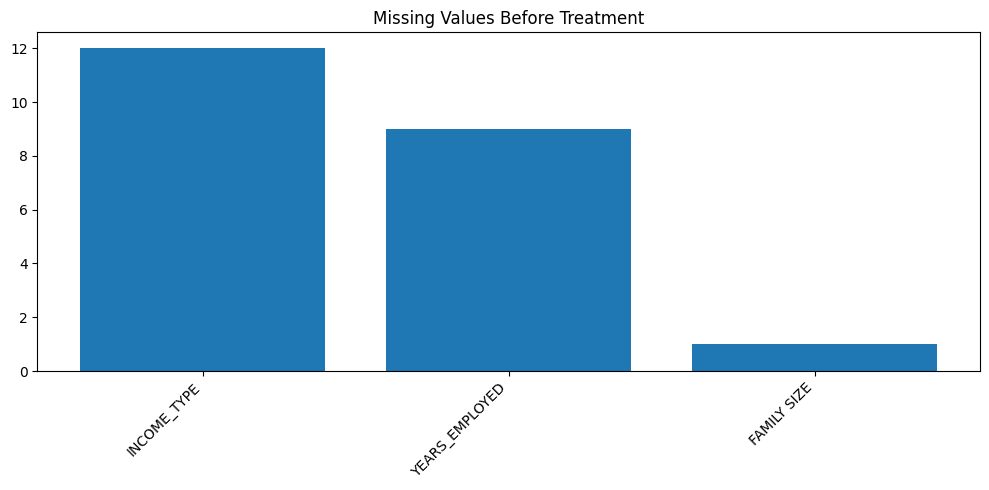

In [7]:

missing_summary_before = pd.DataFrame({"Column": data.columns, "Missing_Count": data.isnull().sum().values})
missing_summary_before["Missing_Percentage"] = (missing_summary_before["Missing_Count"] / len(data) * 100).round(3)
missing_summary_before = missing_summary_before.sort_values(by="Missing_Count", ascending=False)

missing_summary_before.to_csv("tables/missing_summary_before_treatment.csv", index=False)
display(missing_summary_before)

missing_nonzero = missing_summary_before[missing_summary_before["Missing_Count"] > 0]
if len(missing_nonzero) > 0:
    plt.figure(figsize=(10, 5))
    plt.bar(missing_nonzero["Column"], missing_nonzero["Missing_Count"])
    plt.title("Missing Values Before Treatment")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("figures/missing_values_before_treatment.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No missing values detected before treatment.")


## Task 2B – Preprocessing

In [8]:

data_clean = data.copy()

numeric_columns = data_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = data_clean.select_dtypes(exclude=[np.number]).columns.tolist()

for col in numeric_columns:
    data_clean[col] = data_clean[col].fillna(data_clean[col].median())

for col in categorical_columns:
    mode_value = data_clean[col].mode(dropna=True)
    fill_value = mode_value.iloc[0] if len(mode_value) > 0 else "Unknown"
    data_clean[col] = data_clean[col].fillna(fill_value)

missing_summary_after = pd.DataFrame({"Column": data_clean.columns, "Missing_Count": data_clean.isnull().sum().values})
missing_summary_after["Missing_Percentage"] = (missing_summary_after["Missing_Count"] / len(data_clean) * 100).round(3)
missing_summary_after.to_csv("tables/missing_summary_after_treatment.csv", index=False)
display(missing_summary_after.sort_values(by="Missing_Count", ascending=False).head(20))


,Column,Missing_Count,Missing_Percentage
0,Unnamed: 0,0,0.0
1,ID,0,0.0
2,GENDER,0,0.0
3,CAR,0,0.0
4,REALITY,0,0.0
5,NO_OF_CHILD,0,0.0
6,FAMILY_TYPE,0,0.0
7,HOUSE_TYPE,0,0.0
8,FLAG_MOBIL,0,0.0
9,WORK_PHONE,0,0.0


In [9]:

candidate_numeric_cols = [col for col in ["NO_OF_CHILD", "FAMILY SIZE", "BEGIN_MONTH", "AGE", "YEARS_EMPLOYED", "INCOME"] if col in data_clean.columns]

data_capped = data_clean.copy()
outlier_records = []

for col in candidate_numeric_cols:
    q1 = data_capped[col].quantile(0.25)
    q3 = data_capped[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = int(((data_capped[col] < lower_bound) | (data_capped[col] > upper_bound)).sum())
    outlier_records.append({
        "Column": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count_Before_Capping": outlier_count,
        "Outlier_Percentage_Before_Capping": round(outlier_count / len(data_capped) * 100, 3)
    })
    data_capped[col] = data_capped[col].clip(lower=lower_bound, upper=upper_bound)

outlier_summary = pd.DataFrame(outlier_records)
outlier_summary.to_csv("tables/outlier_summary.csv", index=False)
display(outlier_summary)


,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count_Before_Capping,Outlier_Percentage_Before_Capping
0,NO_OF_CHILD,0.0,1.0,1.0,-1.5,2.5,393,1.564
1,FAMILY SIZE,2.0,3.0,1.0,0.5,4.5,382,1.520
2,BEGIN_MONTH,12.0,39.0,27.0,-28.5,79.5,0,0.000
3,AGE,33.0,48.0,15.0,10.5,70.5,5,0.020
4,YEARS_EMPLOYED,3.0,10.0,7.0,-7.5,20.5,1247,4.961
5,INCOME,135000.0,225000.0,90000.0,0.0,360000.0,1180,4.695


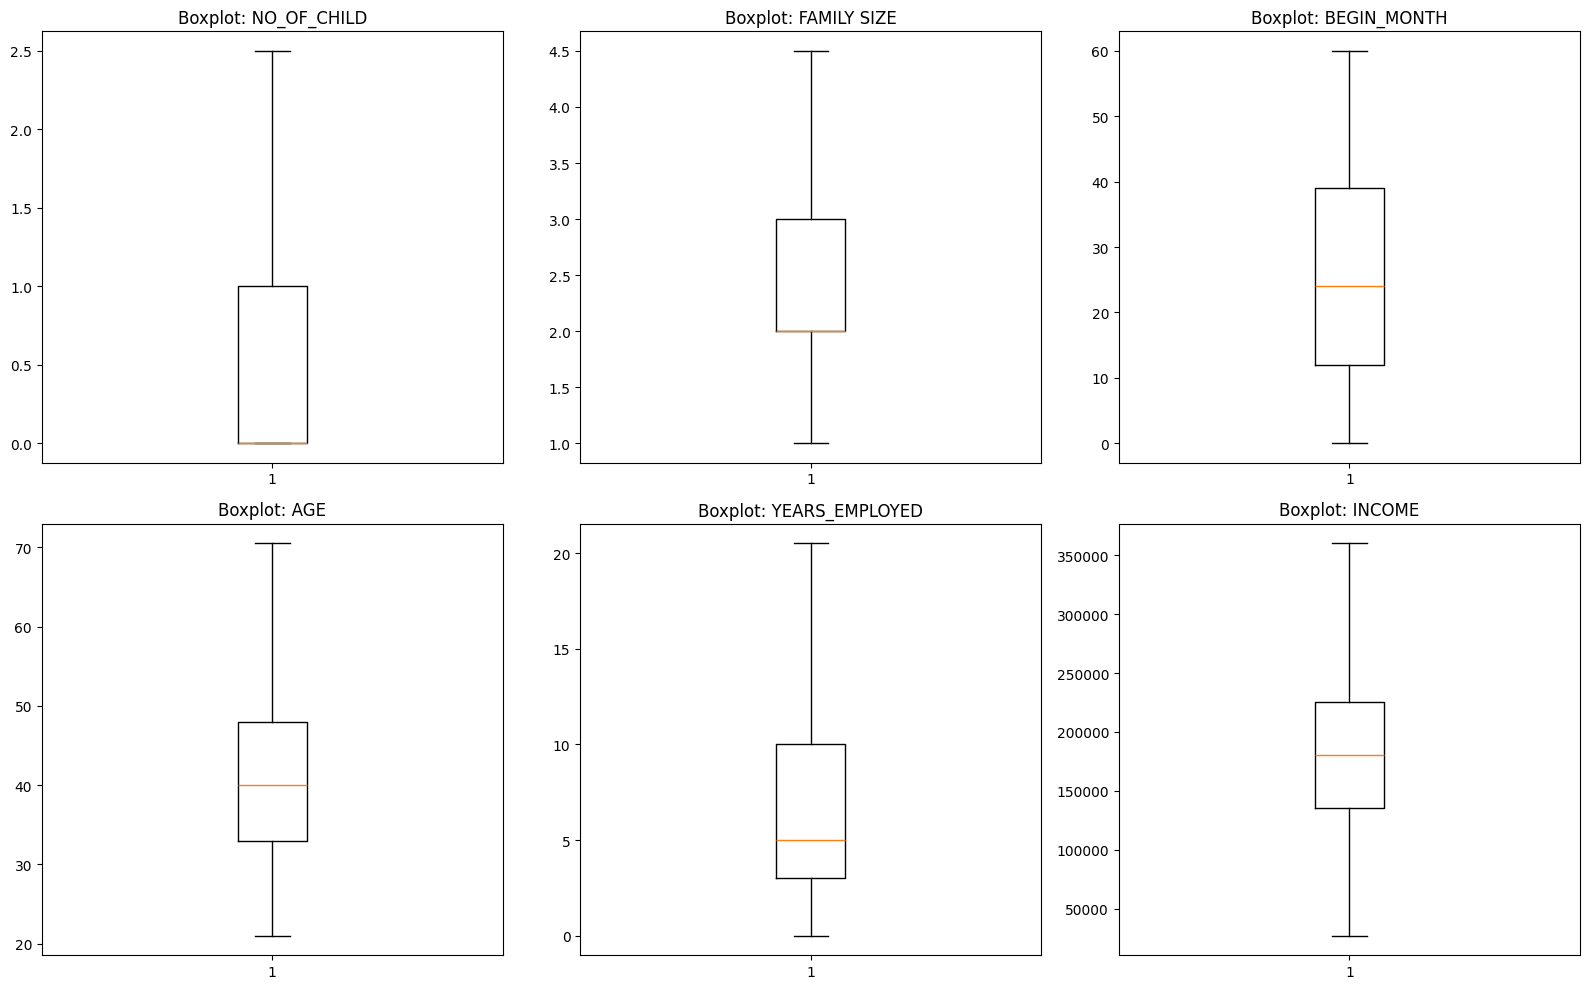

In [10]:

plt.figure(figsize=(16, 10))
for i, col in enumerate(candidate_numeric_cols, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(data_capped[col].dropna(), vert=True)
    plt.title(f"Boxplot: {col}")

plt.tight_layout()
plt.savefig("figures/boxplots_after_outlier_capping.png", dpi=300, bbox_inches="tight")
plt.show()


## Task 2C – Statistical analysis and visualisation

In [11]:

numerical_stats = data_capped.describe(include=[np.number]).T
numerical_stats.to_csv("tables/numerical_statistics.csv")
display(numerical_stats)

categorical_summary = []
for col in data_capped.select_dtypes(exclude=[np.number]).columns:
    vc = data_capped[col].value_counts(dropna=False)
    categorical_summary.append({
        "Column": col,
        "Most_Frequent_Value": vc.index[0] if len(vc) > 0 else np.nan,
        "Frequency": vc.iloc[0] if len(vc) > 0 else np.nan
    })

categorical_summary_df = pd.DataFrame(categorical_summary)
categorical_summary_df.to_csv("tables/categorical_summary.csv", index=False)
display(categorical_summary_df)


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,25134.0,1.256650e+04,7255.705169,0.0,6283.25,12566.5,18849.75,25133.0
ID,25134.0,5.078838e+06,41941.018788,5008806.0,5042228.25,5079004.0,5115603.75,5150487.0
NO_OF_CHILD,25134.0,4.985478e-01,0.724359,0.0,0.00,0.0,1.00,2.5
FLAG_MOBIL,25134.0,1.000000e+00,0.000000,1.0,1.00,1.0,1.00,1.0
WORK_PHONE,25134.0,2.738124e-01,0.445923,0.0,0.00,0.0,1.00,1.0
PHONE,25134.0,2.927906e-01,0.455052,0.0,0.00,0.0,1.00,1.0
E_MAIL,25134.0,1.006605e-01,0.300885,0.0,0.00,0.0,0.00,1.0
FAMILY SIZE,25134.0,2.280894e+00,0.896227,1.0,2.00,2.0,3.00,4.5
BEGIN_MONTH,25134.0,2.612059e+01,16.439658,0.0,12.00,24.0,39.00,60.0
AGE,25134.0,4.054235e+01,9.568012,21.0,33.00,40.0,48.00,70.5


,Column,Most_Frequent_Value,Frequency
0,GENDER,F,15630
1,CAR,N,14618
2,REALITY,Y,16461
3,FAMILY_TYPE,Married,17509
4,HOUSE_TYPE,House / apartment,22102
5,INCOME_TYPE,Working,15626
6,EDUCATION_TYPE,Secondary / secondary special,16808


,TARGET,Count,Percentage
0,0,24712,98.321
1,1,422,1.679


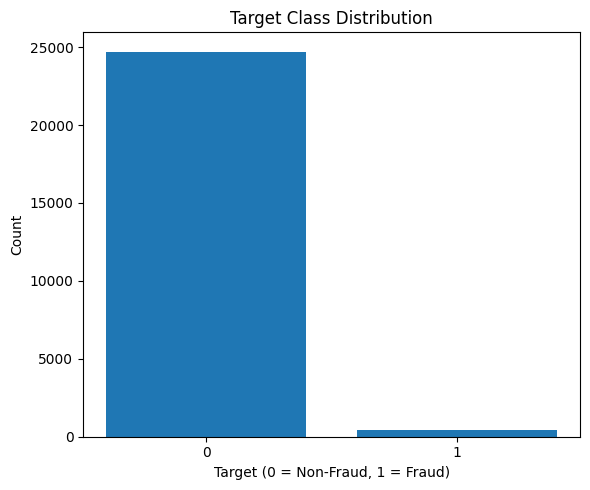

In [12]:

class_distribution = data_capped["TARGET"].value_counts().sort_index()
class_distribution_df = class_distribution.rename_axis("TARGET").reset_index(name="Count")
class_distribution_df["Percentage"] = (class_distribution_df["Count"] / len(data_capped) * 100).round(3)
class_distribution_df.to_csv("tables/class_distribution.csv", index=False)
display(class_distribution_df)

plt.figure(figsize=(6, 5))
plt.bar(class_distribution_df["TARGET"].astype(str), class_distribution_df["Count"])
plt.title("Target Class Distribution")
plt.xlabel("Target (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/target_class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


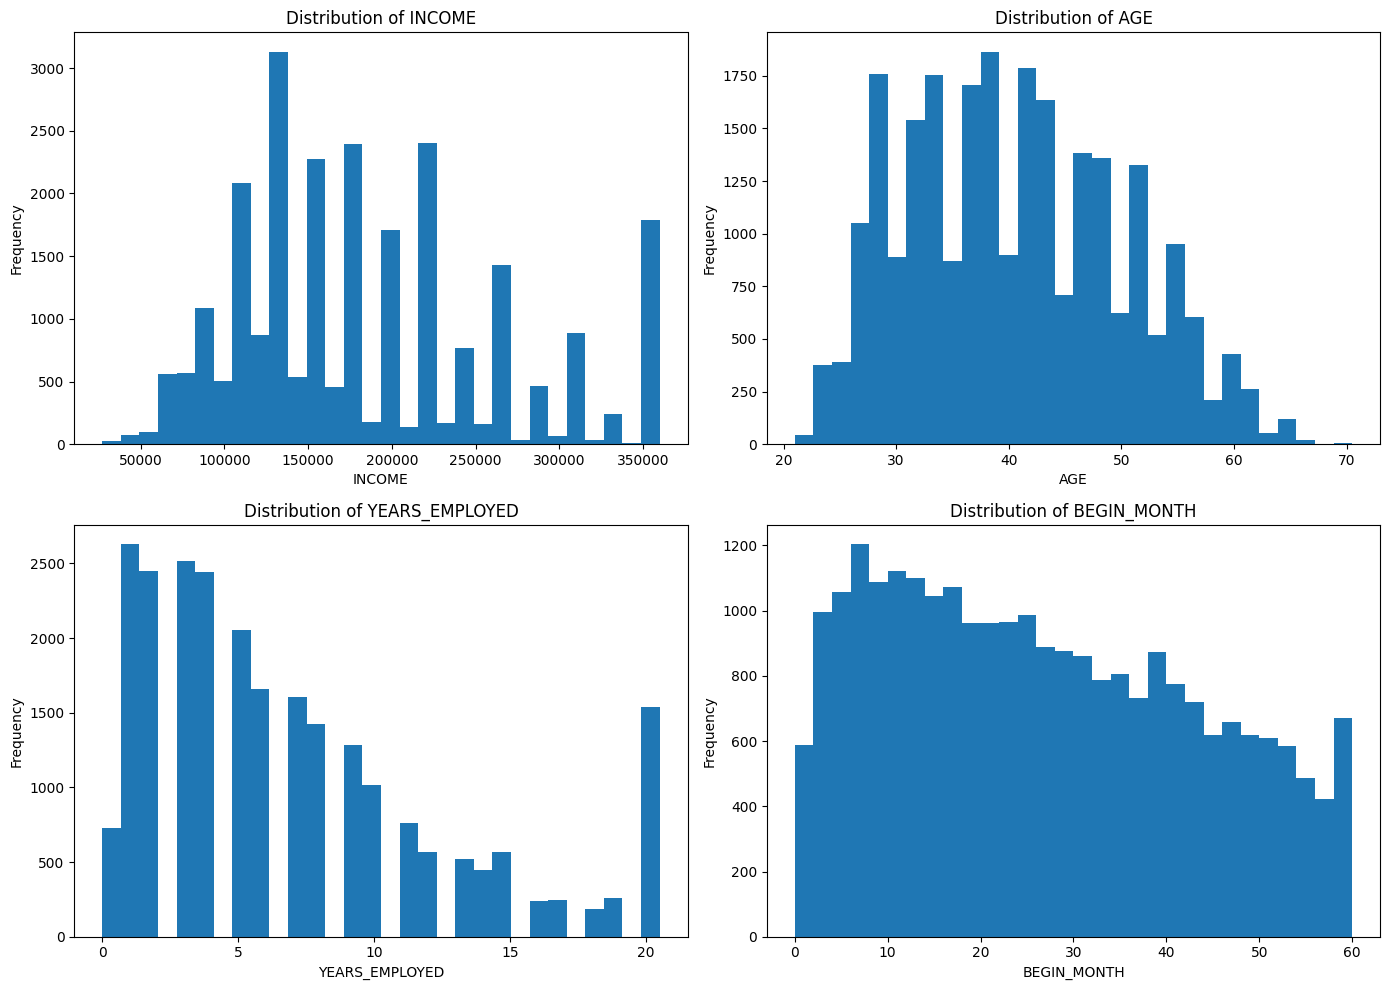

In [13]:

numeric_plot_cols = [col for col in ["INCOME", "AGE", "YEARS_EMPLOYED", "BEGIN_MONTH"] if col in data_capped.columns]

plt.figure(figsize=(14, 10))
for i, col in enumerate(numeric_plot_cols, 1):
    plt.subplot(2, 2, i)
    plt.hist(data_capped[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("figures/numerical_distributions.png", dpi=300, bbox_inches="tight")
plt.show()


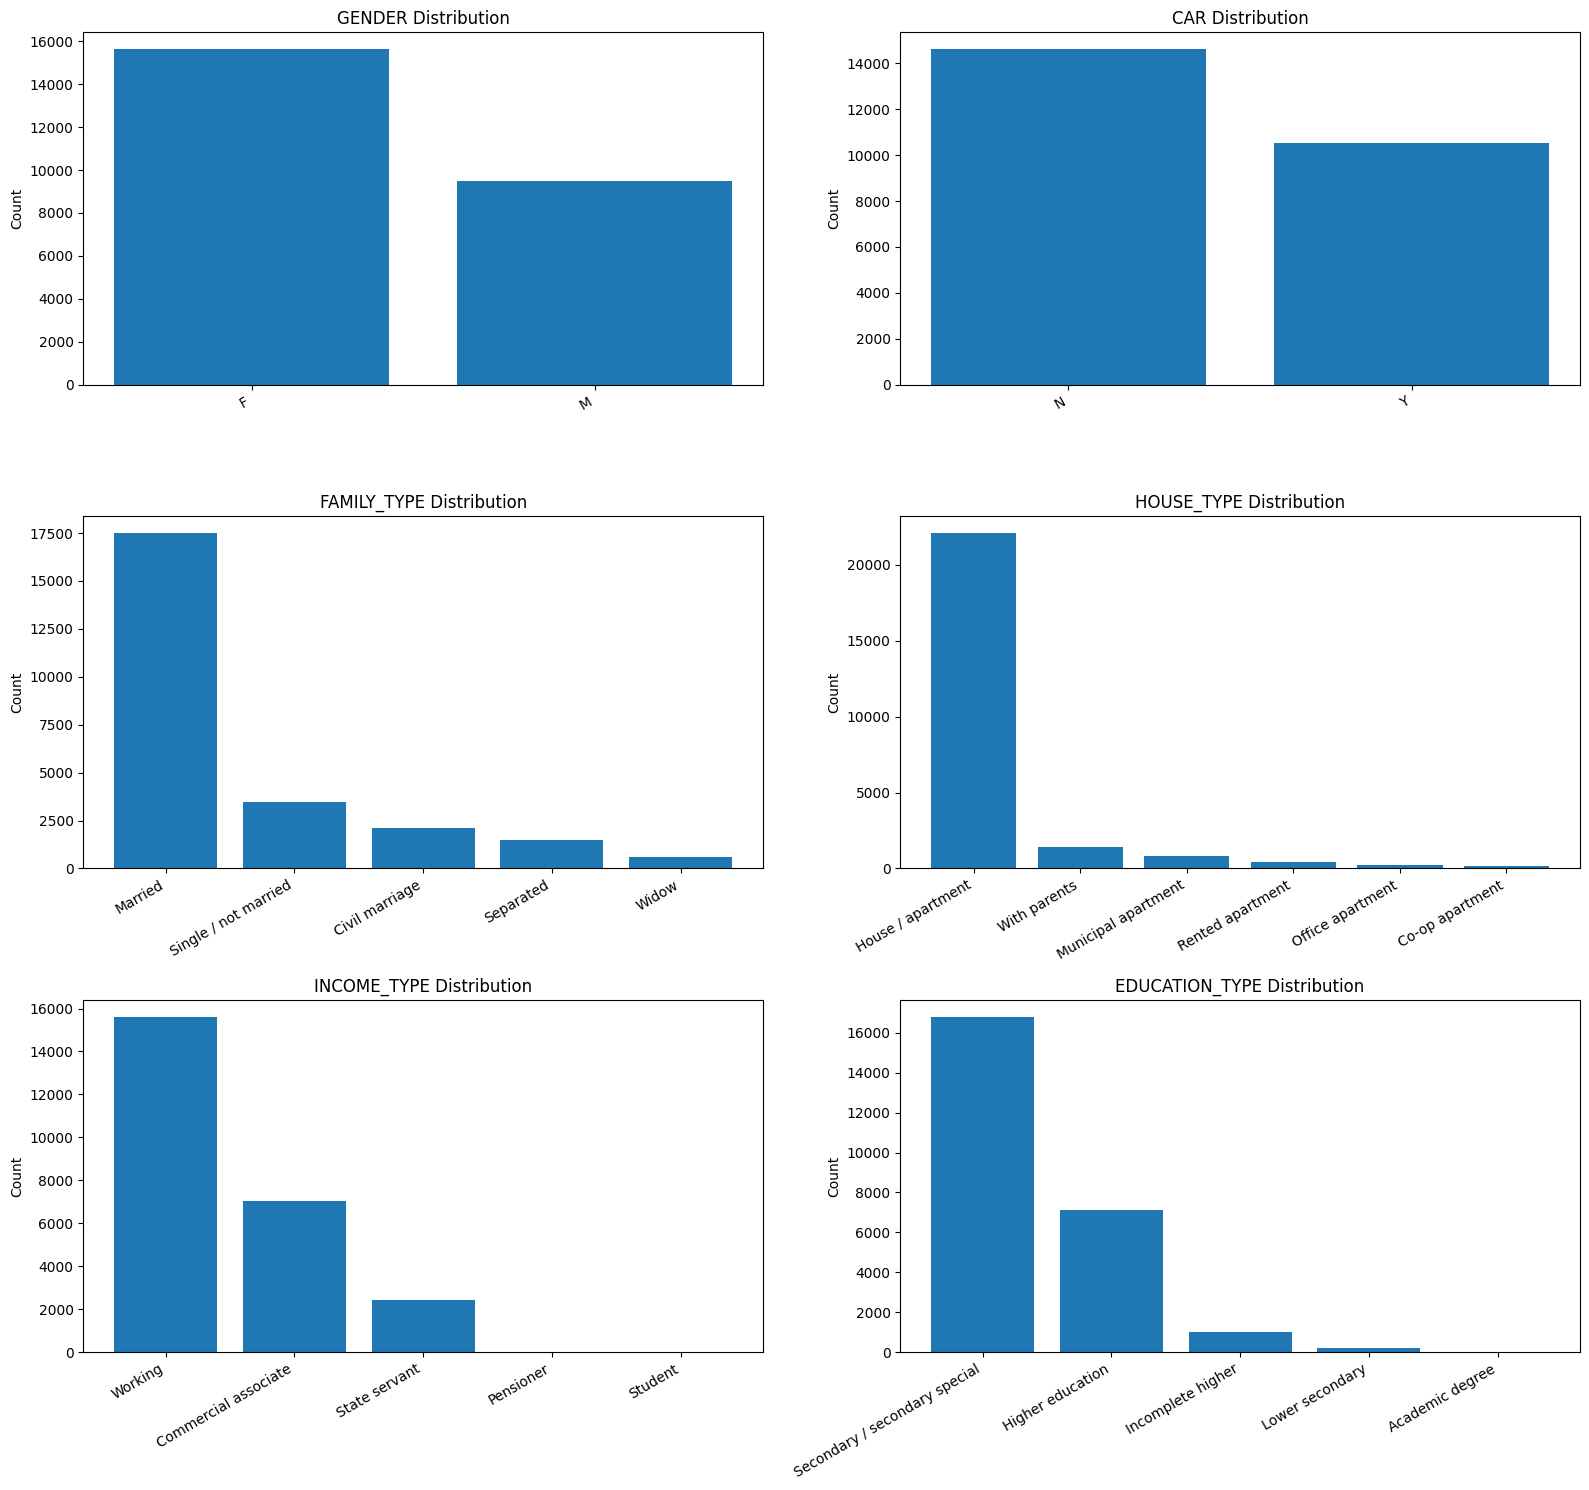

In [14]:

categorical_plot_cols = [col for col in ["GENDER", "CAR", "FAMILY_TYPE", "HOUSE_TYPE", "INCOME_TYPE", "EDUCATION_TYPE"] if col in data_capped.columns]

ncols = 2
nrows = int(np.ceil(len(categorical_plot_cols) / ncols))

plt.figure(figsize=(16, 5 * nrows))
for i, col in enumerate(categorical_plot_cols, 1):
    plt.subplot(nrows, ncols, i)
    counts = data_capped[col].value_counts()
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Count")

plt.tight_layout()
plt.savefig("figures/categorical_distributions.png", dpi=300, bbox_inches="tight")
plt.show()


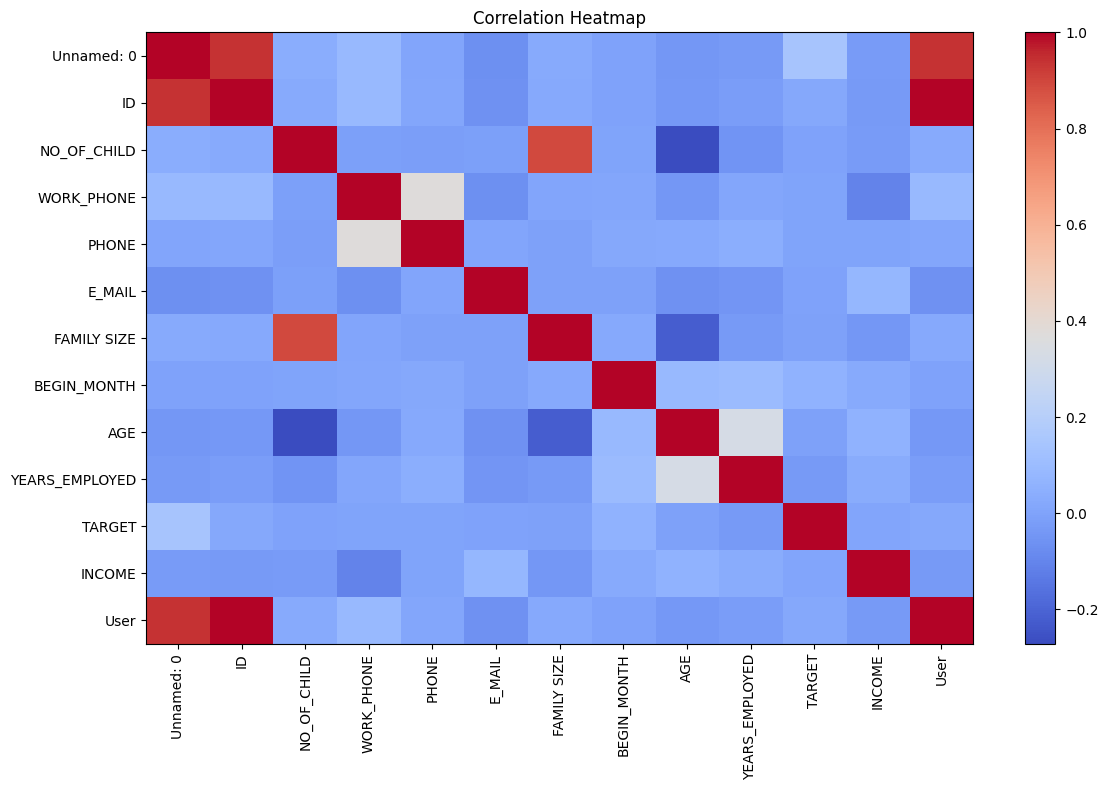

In [15]:

numeric_data = data_capped.select_dtypes(include=[np.number]).copy()
constant_cols = [col for col in numeric_data.columns if numeric_data[col].nunique() <= 1]
if constant_cols:
    numeric_data = numeric_data.drop(columns=constant_cols)

correlation_matrix = numeric_data.corr()
correlation_matrix.to_csv("tables/correlation_matrix.csv")

plt.figure(figsize=(12, 8))
plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## Task 3 – Model building

In [16]:

data_model = pd.get_dummies(data_capped, drop_first=True)

drop_candidate_cols = ["TARGET", "ID", "User", "Unnamed: 0"]
X = data_model.drop(columns=[c for c in drop_candidate_cols if c in data_model.columns], errors="ignore")
y = data_model["TARGET"].astype(int)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
X.head().to_csv("tables/model_feature_preview.csv", index=False)


Feature matrix shape: (25134, 30)
Target shape: (25134,)


In [17]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

split_summary = pd.DataFrame({
    "Dataset": ["X_train", "X_test", "y_train", "y_test"],
    "Shape": [str(X_train.shape), str(X_test.shape), str(y_train.shape), str(y_test.shape)]
})
split_summary.to_csv("tables/train_test_split_summary.csv", index=False)
display(split_summary)

X_train.to_csv("tables/X_train.csv", index=False)
X_test.to_csv("tables/X_test.csv", index=False)
y_train.to_csv("tables/y_train.csv", index=False)
y_test.to_csv("tables/y_test.csv", index=False)


,Dataset,Shape
0,X_train,"(20107, 30)"
1,X_test,"(5027, 30)"
2,y_train,"(20107,)"
3,y_test,"(5027,)"


In [18]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, "models/standard_scaler.pkl")
print("Scaling complete.")


Scaling complete.


In [20]:

def evaluate_model(model_name, y_true, y_pred, y_prob=None):
    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1_Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan
    }
    metrics_df = pd.DataFrame([result])
    metrics_df.to_csv(f"tables/{model_name}_metrics.csv", index=False)

    with open(f"logs/{model_name}_classification_report.txt", "w") as f:
        f.write(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    pd.DataFrame(cm, index=["Actual_0", "Actual_1"], columns=["Pred_0", "Pred_1"]).to_csv(f"tables/{model_name}_confusion_matrix.csv")

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")
    plt.colorbar()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.xticks([0,1], ["Pred_0","Pred_1"])
    plt.yticks([0,1], ["Actual_0","Actual_1"])
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"figures/{model_name}_confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()
    return metrics_df


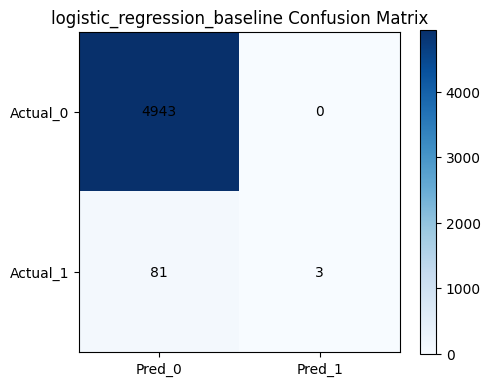

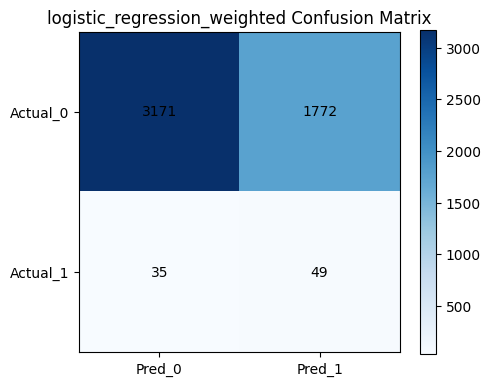

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,logistic_regression_baseline,0.983887,1.000000,0.035714,0.068966,0.652490
1,logistic_regression_weighted,0.640541,0.026908,0.583333,0.051444,0.663185


In [21]:

lr_baseline = LogisticRegression(max_iter=2000, random_state=42)
lr_baseline.fit(X_train_scaled, y_train)
y_pred_lr_baseline = lr_baseline.predict(X_test_scaled)
y_prob_lr_baseline = lr_baseline.predict_proba(X_test_scaled)[:, 1]
lr_baseline_results = evaluate_model("logistic_regression_baseline", y_test, y_pred_lr_baseline, y_prob_lr_baseline)

lr_weighted = LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced")
lr_weighted.fit(X_train_scaled, y_train)
y_pred_lr_weighted = lr_weighted.predict(X_test_scaled)
y_prob_lr_weighted = lr_weighted.predict_proba(X_test_scaled)[:, 1]
lr_weighted_results = evaluate_model("logistic_regression_weighted", y_test, y_pred_lr_weighted, y_prob_lr_weighted)

joblib.dump(lr_baseline, "models/logistic_regression_baseline.pkl")
joblib.dump(lr_weighted, "models/logistic_regression_weighted.pkl")
display(pd.concat([lr_baseline_results, lr_weighted_results], ignore_index=True))


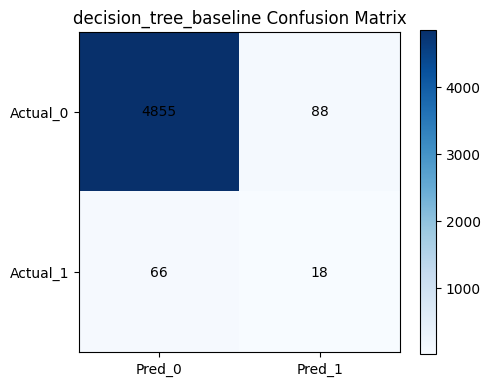

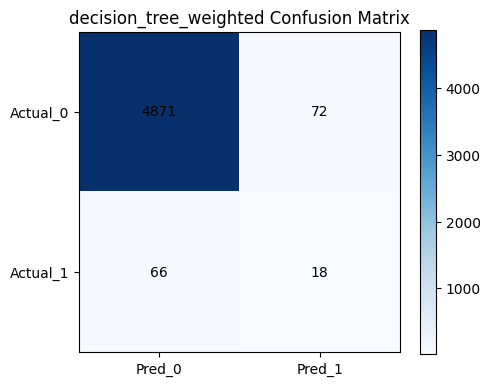

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,decision_tree_baseline,0.969365,0.169811,0.214286,0.189474,0.609450
1,decision_tree_weighted,0.972548,0.200000,0.214286,0.206897,0.599748


In [22]:

dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)
y_pred_dt_baseline = dt_baseline.predict(X_test)
y_prob_dt_baseline = dt_baseline.predict_proba(X_test)[:, 1]
dt_baseline_results = evaluate_model("decision_tree_baseline", y_test, y_pred_dt_baseline, y_prob_dt_baseline)

dt_weighted = DecisionTreeClassifier(random_state=42, class_weight="balanced")
dt_weighted.fit(X_train, y_train)
y_pred_dt_weighted = dt_weighted.predict(X_test)
y_prob_dt_weighted = dt_weighted.predict_proba(X_test)[:, 1]
dt_weighted_results = evaluate_model("decision_tree_weighted", y_test, y_pred_dt_weighted, y_prob_dt_weighted)

joblib.dump(dt_baseline, "models/decision_tree_baseline.pkl")
joblib.dump(dt_weighted, "models/decision_tree_weighted.pkl")
display(pd.concat([dt_baseline_results, dt_weighted_results], ignore_index=True))


In [23]:

dt_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    param_grid=dt_param_grid,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1
)
dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_
best_dt_params = pd.DataFrame([dt_grid.best_params_])
best_dt_params["Best_CV_F1"] = dt_grid.best_score_
best_dt_params.to_csv("tables/best_decision_tree_parameters.csv", index=False)
display(best_dt_params)


,criterion,max_depth,min_samples_leaf,min_samples_split,Best_CV_F1
0,entropy,None,1,2,0.18481


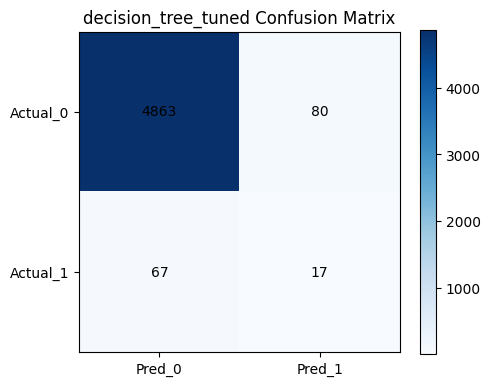

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,decision_tree_tuned,0.970758,0.175258,0.202381,0.187845,0.593019


In [24]:

y_pred_best_dt = best_dt.predict(X_test)
y_prob_best_dt = best_dt.predict_proba(X_test)[:, 1]
dt_tuned_results = evaluate_model("decision_tree_tuned", y_test, y_pred_best_dt, y_prob_best_dt)
joblib.dump(best_dt, "models/decision_tree_tuned.pkl")
display(dt_tuned_results)


In [25]:

cv_results = []

lr_weighted_cv = cross_val_score(
    LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced"),
    X_train_scaled, y_train, cv=cv_strategy, scoring="f1", n_jobs=-1
)
cv_results.append({"Model": "Logistic Regression Weighted", "CV_F1_Mean": lr_weighted_cv.mean(), "CV_F1_STD": lr_weighted_cv.std()})

dt_weighted_cv = cross_val_score(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    X_train, y_train, cv=cv_strategy, scoring="f1", n_jobs=-1
)
cv_results.append({"Model": "Decision Tree Weighted", "CV_F1_Mean": dt_weighted_cv.mean(), "CV_F1_STD": dt_weighted_cv.std()})

dt_tuned_cv = cross_val_score(best_dt, X_train, y_train, cv=cv_strategy, scoring="f1", n_jobs=-1)
cv_results.append({"Model": "Decision Tree Tuned", "CV_F1_Mean": dt_tuned_cv.mean(), "CV_F1_STD": dt_tuned_cv.std()})

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.to_csv("tables/cross_validation_results.csv", index=False)
display(cv_results_df)


,Model,CV_F1_Mean,CV_F1_STD
0,Logistic Regression Weighted,0.051757,0.002575
1,Decision Tree Weighted,0.184283,0.046182
2,Decision Tree Tuned,0.184810,0.041264


In [26]:

final_results = pd.concat([
    lr_baseline_results,
    lr_weighted_results,
    dt_baseline_results,
    dt_weighted_results,
    dt_tuned_results
], ignore_index=True).sort_values(by="F1_Score", ascending=False)

final_results.to_csv("tables/final_model_comparison.csv", index=False)
display(final_results)


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
3,decision_tree_weighted,0.972548,0.200000,0.214286,0.206897,0.599748
2,decision_tree_baseline,0.969365,0.169811,0.214286,0.189474,0.609450
4,decision_tree_tuned,0.970758,0.175258,0.202381,0.187845,0.593019
0,logistic_regression_baseline,0.983887,1.000000,0.035714,0.068966,0.652490
1,logistic_regression_weighted,0.640541,0.026908,0.583333,0.051444,0.663185


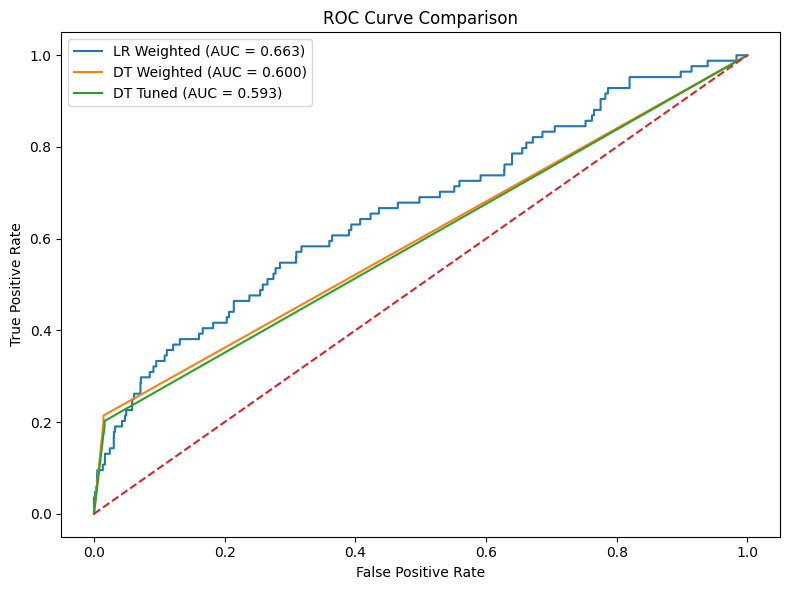

In [27]:

model_probabilities = {"LR Weighted": y_prob_lr_weighted, "DT Weighted": y_prob_dt_weighted, "DT Tuned": y_prob_best_dt}

plt.figure(figsize=(8, 6))
for name, probs in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("figures/roc_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


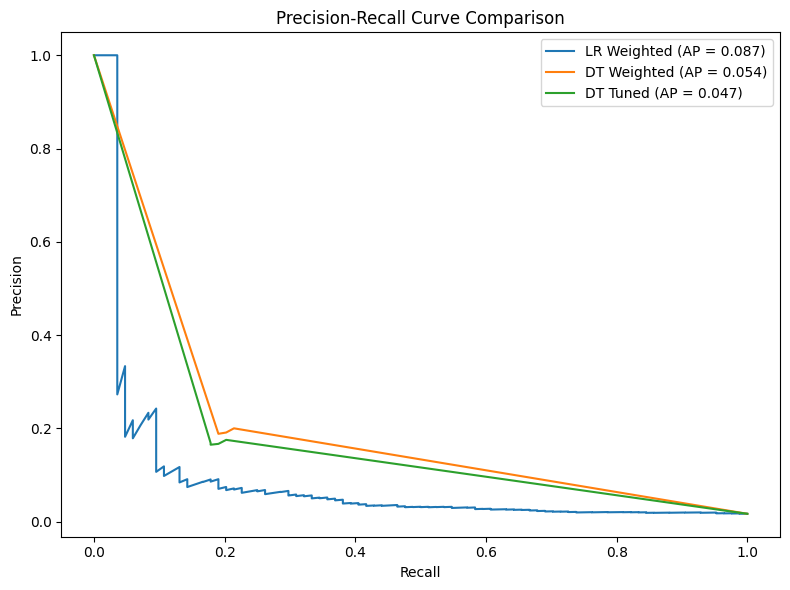

In [28]:

plt.figure(figsize=(8, 6))
for name, probs in model_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("figures/precision_recall_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


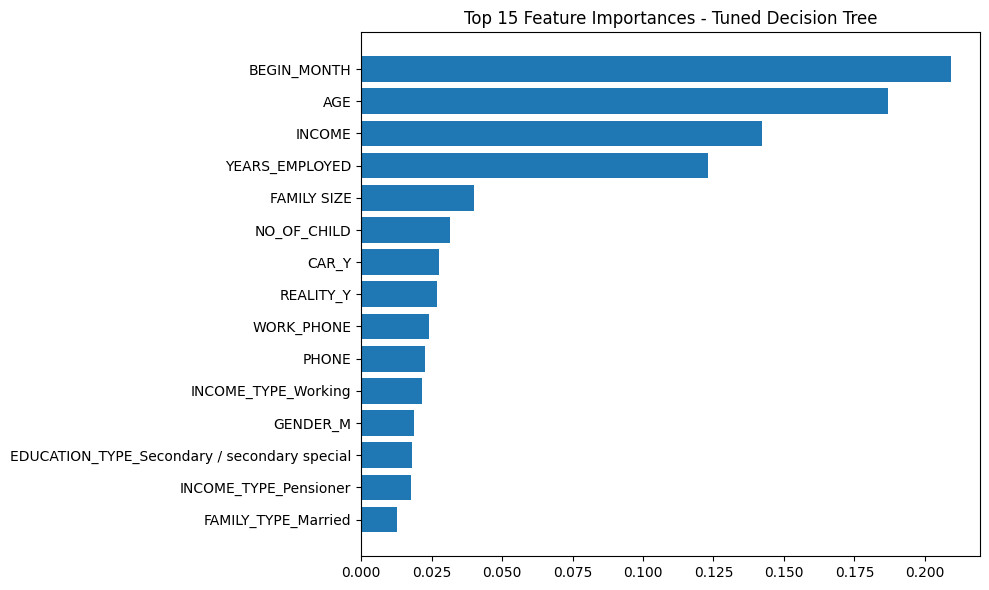

,Feature,Importance
6,BEGIN_MONTH,0.209108
7,AGE,0.186930
9,INCOME,0.142102
8,YEARS_EMPLOYED,0.122952
5,FAMILY SIZE,0.040175
0,NO_OF_CHILD,0.031471
11,CAR_Y,0.027665
12,REALITY_Y,0.027031
2,WORK_PHONE,0.024044
3,PHONE,0.022743


In [29]:

feature_importance = pd.DataFrame({"Feature": X.columns, "Importance": best_dt.feature_importances_}).sort_values(by="Importance", ascending=False)
feature_importance.to_csv("tables/decision_tree_feature_importance.csv", index=False)
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - Tuned Decision Tree")
plt.tight_layout()
plt.savefig("figures/top15_feature_importance_tuned_dt.png", dpi=300, bbox_inches="tight")
plt.show()

display(top_features)


In [30]:

completion_checklist = pd.DataFrame([
    ["Task 1 - Dataset import", "Done"],
    ["Task 1 - Dataset merge", "Done"],
    ["Task 2A - Shape, columns, data types", "Done"],
    ["Task 2A - Missing value analysis", "Done"],
    ["Task 2A - Unique value summary", "Done"],
    ["Task 2B - Missing value treatment", "Done"],
    ["Task 2B - Duplicate analysis", "Done"],
    ["Task 2B - Outlier analysis", "Done"],
    ["Task 2B - Outlier capping", "Done"],
    ["Task 2B - Encoding", "Done"],
    ["Task 2C - Descriptive statistics", "Done"],
    ["Task 2C - Numerical visualisations", "Done"],
    ["Task 2C - Categorical visualisations", "Done"],
    ["Task 2C - Correlation heatmap", "Done"],
    ["Task 3 - Logistic Regression", "Done"],
    ["Task 3 - Decision Tree", "Done"],
    ["Task 3 - Metrics comparison", "Done"],
    ["Task 3 - Model improvement using tuning", "Done"],
    ["Task 3 - Cross-validation", "Done"],
    ["Task 4 - GUI", "Not included in this notebook"],
    ["Task 5 - GitHub screenshot evidence", "To be added manually"]
], columns=["Requirement", "Status"])

completion_checklist.to_csv("tables/completion_checklist.csv", index=False)
display(completion_checklist)


,Requirement,Status
0,Task 1 - Dataset import,Done
1,Task 1 - Dataset merge,Done
2,"Task 2A - Shape, columns, data types",Done
3,Task 2A - Missing value analysis,Done
4,Task 2A - Unique value summary,Done
5,Task 2B - Missing value treatment,Done
6,Task 2B - Duplicate analysis,Done
7,Task 2B - Outlier analysis,Done
8,Task 2B - Outlier capping,Done
9,Task 2B - Encoding,Done


In [31]:

with open("reports/final_summary_report.txt", "w") as f:
    f.write("Fraud Detection Analysis Summary\n")
    f.write("="*50 + "\n\n")
    f.write(f"Merged dataset shape: {data.shape}\n")
    f.write(f"Feature matrix shape: {X.shape}\n\n")
    f.write("Class distribution:\n")
    f.write(class_distribution_df.to_string(index=False))
    f.write("\n\nFinal model comparison:\n")
    f.write(final_results.to_string(index=False))
    f.write("\n\nBest Decision Tree Parameters:\n")
    f.write(best_dt_params.to_string(index=False))
    f.write("\n\nCross-validation results:\n")
    f.write(cv_results_df.to_string(index=False))
print("Summary report saved successfully.")


Summary report saved successfully.


In [32]:

print("Notebook executed successfully from top to bottom.")
print("Saved outputs in figures/, tables/, logs/, models/, and reports/.")


Notebook executed successfully from top to bottom.
Saved outputs in figures/, tables/, logs/, models/, and reports/.
